In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("/content/winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
import tensorflow as tf

#75% of data for training
train_df=df.sample(frac=0.75,random_state=42)

val_df=df.drop(train_df.index)

In [5]:
max_val=train_df.max(axis=0)
min_val=train_df.min(axis=0)

range = max_val-min_val
train_df=(train_df-min_val)/(range)
val_df=(val_df-min_val)/range

In [6]:
x_train=train_df.drop('quality',axis=1)
x_val=val_df.drop('quality',axis=1)
y_train=train_df['quality']
y_val=val_df['quality']

input_shape=[x_train.shape[1]]
input_shape

[11]

In [11]:
# Linear  Model
model=tf.keras.Sequential([tf.keras.layers.Dense(units=1,input_shape=input_shape)])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12 (48.00 B)

 Trainable params: 12 (48.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:

model=tf.keras.Sequential([tf.keras.layers.Dense(units=64,activation='relu',input_shape=input_shape),
                           tf.keras.layers.Dense(units=64,activation='relu'),
                           tf.keras.layers.Dense(units=1)])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,993 (19.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='adam',loss='mae')

In [15]:
losses=model.fit(x_train,y_train,validation_data=(x_val,y_val),
                 batch_size=256 , epochs=15)

Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1368 - val_loss: 0.1295
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1340 - val_loss: 0.1224
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1275 - val_loss: 0.1153
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1225 - val_loss: 0.1115
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1188 - val_loss: 0.1069
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1148 - val_loss: 0.1020
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1122 - val_loss: 0.0994
Epoch 8/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1104 - val_loss: 0.0973
Epoch 9/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1093 - val_loss: 0.0959
Epoch 10/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1082 - val_loss: 0.0943
Epoch 11/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1076 - val_loss: 0.0935
Epoch 12/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1068 - val_loss: 0.0928
E

In [16]:
model.predict(x_val.iloc[0:3,:])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


array([[0.4523179 ],
       [0.41624326],
       [0.52581024]], dtype=float32)

In [17]:
y_val.iloc[0:3]

,quality
1,0.4
8,0.8
13,0.4


<Axes: >

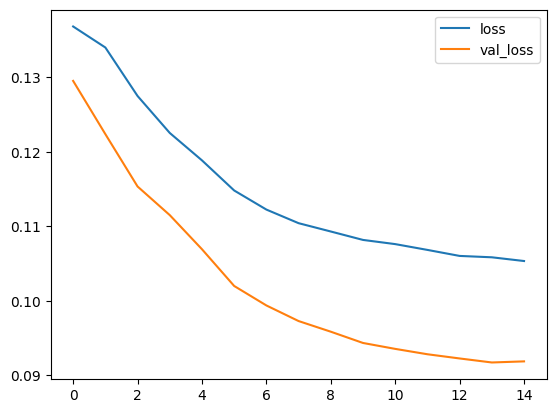

In [18]:
loss_df=pd.DataFrame(losses.history)
loss_df.loc[:,['loss','val_loss']].plot()